In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crime-cast-forecasting-crime-categories/sample.csv
/kaggle/input/crime-cast-forecasting-crime-categories/train.csv
/kaggle/input/crime-cast-forecasting-crime-categories/test.csv


In [2]:
#Importing Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from scipy.stats import randint, uniform
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style="whitegrid")

In [3]:
#Reading the training dataset
df = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/train.csv")
df.head()

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category
0,4500 CARPENTER AV,NaN,34.1522,-118.3910,03/09/2020 12:00:00 AM,03/06/2020 12:00:00 AM,1800.0,15.0,N Hollywood,1563.0,...,75.0,M,W,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
1,45TH ST,ALAMEDA ST,34.0028,-118.2391,02/27/2020 12:00:00 AM,02/27/2020 12:00:00 AM,1345.0,13.0,Newton,1367.0,...,41.0,M,H,216.0,SWAP MEET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
2,600 E MARTIN LUTHER KING JR BL,NaN,34.0111,-118.2653,08/21/2020 12:00:00 AM,08/21/2020 12:00:00 AM,605.0,13.0,Newton,1343.0,...,67.0,M,B,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Property Crimes
3,14900 ORO GRANDE ST,NaN,34.2953,-118.4590,11/08/2020 12:00:00 AM,11/06/2020 12:00:00 AM,1800.0,19.0,Mission,1924.0,...,61.0,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
4,7100 S VERMONT AV,NaN,33.9787,-118.2918,02/25/2020 12:00:00 AM,02/25/2020 12:00:00 AM,1130.0,12.0,77th Street,1245.0,...,0.0,X,X,401.0,MINI-MART,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes


In [4]:
#Getting the shape
df.shape

(20000, 22)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


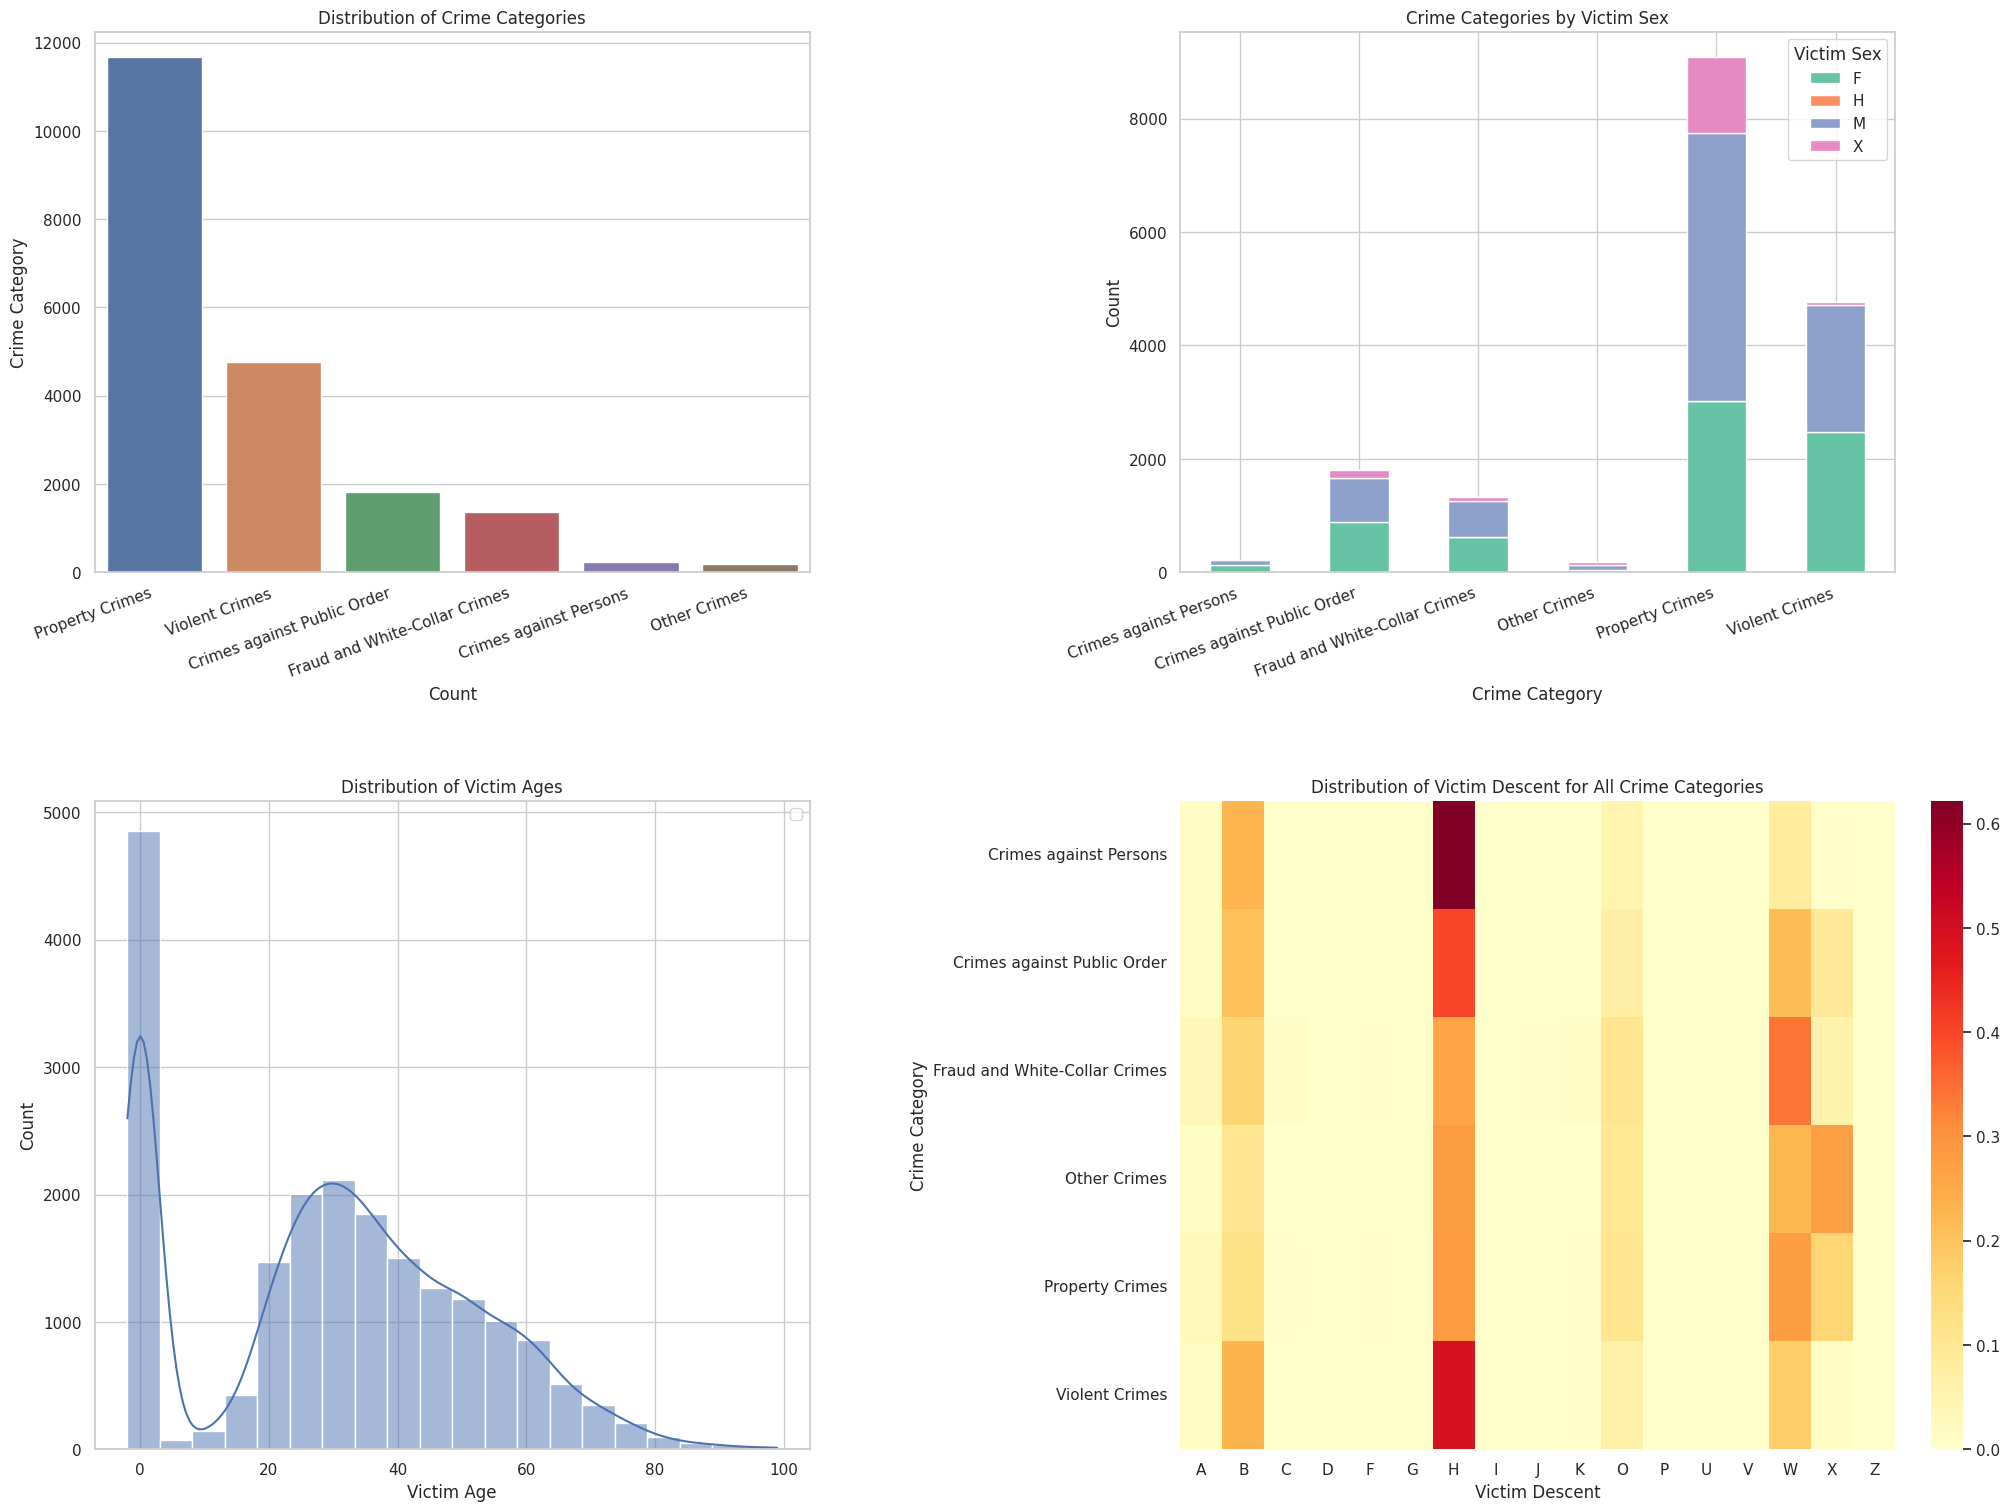

In [5]:
#Main Plot
fig = plt.figure(figsize=(20, 15), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], width_ratios=[1, 1], hspace=0.1, wspace=0.1)

#Plot 1: Distribution of crime categories
ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(x='Crime_Category', data=df, order=df['Crime_Category'].value_counts().index)
ax1.set_title('Distribution of Crime Categories')
ax1.set_xlabel('Count')
ax1.set_ylabel('Crime Category')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha='right')

#Plot 2: Stacked Bar Chart for Gender Distribution in Crime Categories
ax2 = fig.add_subplot(gs[0, 1])

#Crime vs Sex Grouped Dataframe
crime_sex = df.groupby(['Crime_Category', 'Victim_Sex']).size().unstack()
crime_sex.plot(kind='bar', stacked=True, ax=ax2, color=sns.color_palette("Set2", n_colors=len(crime_sex.columns)))

#Visual features definition
ax2.set_title('Crime Categories by Victim Sex')
ax2.set_xlabel('Crime Category')
ax2.set_ylabel('Count')
ax2.legend(title='Victim Sex')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha='right')


#Plot 3: Histogram for age group distribution across crime categories
ax3 = fig.add_subplot(gs[1, 0])

#Creating the histogram
sns.histplot(data=df, x='Victim_Age', bins=20, kde=True, ax=ax3)

#Customizing the visual features
ax3.set_title('Distribution of Victim Ages')
ax3.set_xlabel('Victim Age')
ax3.set_ylabel('Count')
ax3.legend()


#Plot 4: Heatmap for descent distribution in crime categories
ax4 = fig.add_subplot(gs[1, 1])
crime_descent = pd.crosstab(df['Crime_Category'], df['Victim_Descent'])

#Normalizing the data
crime_descent_norm = crime_descent.div(crime_descent.sum(axis=1), axis=0)

#Creating the heatmap
sns.heatmap(crime_descent_norm, cmap="YlOrRd", ax=ax4)
ax4.set_title('Distribution of Victim Descent for All Crime Categories')
ax4.set_ylabel('Crime Category')
ax4.set_xlabel('Victim Descent')

plt.show()

### Observations
* Property Crimes are the highest reported crimes.
* More male victims are reported, closely followed by female victims.
* Kids aged between 0 and 5 are generally the highest target category.
* Victims are more likely to be from descent H.

In [6]:
#Separating the target column
X = df.drop('Crime_Category', axis='columns')
y = df['Crime_Category']

In [7]:
#Number of categories per column
X.nunique()

Location                 12399
Cross_Street              1495
Latitude                  3622
Longitude                 3578
Date_Reported              811
Date_Occurred              366
Time_Occurred              996
Area_ID                     21
Area_Name                   21
Reporting_District_no     1120
Part 1-2                     2
Modus_Operandi           10489
Victim_Age                 100
Victim_Sex                   4
Victim_Descent              17
Premise_Code               217
Premise_Description        216
Weapon_Used_Code            57
Weapon_Description          57
Status                       5
Status_Description           5
dtype: int64

In [8]:
#Column Types
X.dtypes

Location                  object
Cross_Street              object
Latitude                 float64
Longitude                float64
Date_Reported             object
Date_Occurred             object
Time_Occurred            float64
Area_ID                  float64
Area_Name                 object
Reporting_District_no    float64
Part 1-2                 float64
Modus_Operandi            object
Victim_Age               float64
Victim_Sex                object
Victim_Descent            object
Premise_Code             float64
Premise_Description       object
Weapon_Used_Code         float64
Weapon_Description        object
Status                    object
Status_Description        object
dtype: object

In [9]:
#Count of Null Values
X.isnull().sum()

Location                     0
Cross_Street             16552
Latitude                     0
Longitude                    0
Date_Reported                0
Date_Occurred                0
Time_Occurred                0
Area_ID                      0
Area_Name                    0
Reporting_District_no        0
Part 1-2                     0
Modus_Operandi            2741
Victim_Age                   0
Victim_Sex                2624
Victim_Descent            2624
Premise_Code                 0
Premise_Description          5
Weapon_Used_Code         12665
Weapon_Description       12665
Status                       0
Status_Description           0
dtype: int64

In [10]:
#Summary statistics for data
X.describe()

,Latitude,Longitude,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Victim_Age,Premise_Code,Weapon_Used_Code
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,7335.000000
mean,33.940704,-117.893072,1352.380350,10.834250,1129.599200,1.418150,30.135000,297.176950,366.405044
std,2.126810,7.377726,646.100291,6.033166,603.330519,0.493267,21.863645,212.007298,120.485687
min,0.000000,-118.663400,1.000000,1.000000,101.000000,1.000000,-2.000000,101.000000,101.000000
25%,34.009200,-118.429700,930.000000,6.000000,632.000000,1.000000,12.000000,101.000000,312.000000
50%,34.058700,-118.323000,1430.000000,11.000000,1162.000000,1.000000,31.000000,203.000000,400.000000
75%,34.165025,-118.274400,1900.000000,16.000000,1622.000000,2.000000,46.000000,501.000000,400.000000
max,34.328100,0.000000,2359.000000,21.000000,2197.000000,2.000000,99.000000,969.000000,515.000000


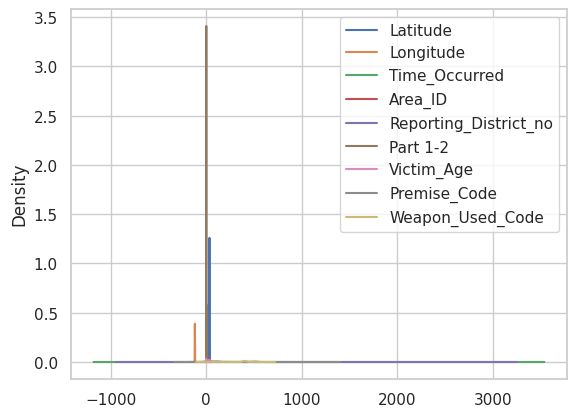

In [11]:
#KDE Plot to view range of data
ax = X.plot.kde()

As we can see, the data is scattered over a very large range and needs to be scaled.

In [12]:
#Function to preprocess data
def data_preprocessing(X):
    #Specifying date format
    date_format = '%m/%d/%Y %I:%M:%S %p'  # Adjust the format to match your date strings

    #Parsing dates with given formats to extract year, month, day and day of the week from date occurred and date reported
    X['Date_Occurred_Year'] = pd.to_datetime(X.Date_Occurred, format=date_format).dt.year
    X['Date_Occurred_Month'] = pd.to_datetime(X.Date_Occurred, format=date_format).dt.month
    X['Date_Occurred_Day'] = pd.to_datetime(X.Date_Occurred, format=date_format).dt.day
    X['Date_Occurred_Dayofweek'] = pd.to_datetime(X.Date_Occurred, format=date_format).dt.dayofweek

    X['Date_Reported_Year'] = pd.to_datetime(X.Date_Reported, format=date_format).dt.year
    X['Date_Reported_Month'] = pd.to_datetime(X.Date_Reported, format=date_format).dt.month
    X['Date_Reported_Day'] = pd.to_datetime(X.Date_Reported, format=date_format).dt.day
    X['Date_Reported_Dayofweek'] = pd.to_datetime(X.Date_Reported, format=date_format).dt.dayofweek
    
    #Dropping repetitive columns which already have an ID/date columns
    X = X.drop(['Area_Name', 'Date_Reported', 'Date_Occurred', 'Premise_Description', 'Weapon_Description', 'Status_Description'], axis='columns')
    
    #Replacing invalid ages with NaN
    X['Victim_Age'] = X['Victim_Age'].replace([0, -1, -2], np.nan)
    
    #Imputing the null values with the modes of the columns
    imputer = SimpleImputer(missing_values = np.nan, strategy ='most_frequent')
    imputed_data = imputer.fit_transform(X)
    imputed_data = pd.DataFrame(imputed_data)
    imputed_data.columns=list(X)
    
    #Initializing Label Encoder
    le = LabelEncoder()

    #Converting categorical features to numerical with LabelEncoder
    imputed_data[['Location', 'Cross_Street', 'Modus_Operandi', 'Victim_Sex', 'Victim_Descent', 'Status']] = imputed_data[['Location', 'Cross_Street', 'Modus_Operandi', 'Victim_Sex', 'Victim_Descent', 'Status']].apply(le.fit_transform)

    #Scaling the data with MinMaxScaler such that it ranges between 0 and 1
    mm = MinMaxScaler()
    X_normalised = mm.fit_transform(imputed_data)
    X_normalised = pd.DataFrame(X_normalised)
    X_normalised.columns=list(imputed_data)
    return X_normalised

X = data_preprocessing(X)
X.head()

,Location,Cross_Street,Latitude,Longitude,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Modus_Operandi,Victim_Age,...,Weapon_Used_Code,Status,Date_Occurred_Year,Date_Occurred_Month,Date_Occurred_Day,Date_Occurred_Dayofweek,Date_Reported_Year,Date_Reported_Month,Date_Reported_Day,Date_Reported_Dayofweek
0,0.583804,0.208835,0.994876,0.002296,0.762935,0.70,0.697519,0.0,0.252002,0.752577,...,0.722222,0.5,0.0,0.181818,0.166667,0.666667,0.0,0.181818,0.266667,0.000000
1,0.588805,0.111780,0.990524,0.003576,0.569975,0.60,0.604008,0.0,0.422864,0.402062,...,0.722222,0.5,0.0,0.090909,0.866667,0.500000,0.0,0.090909,0.866667,0.500000
2,0.687611,0.208835,0.990766,0.003355,0.256149,0.60,0.592557,1.0,0.071606,0.670103,...,0.722222,0.5,0.0,0.636364,0.666667,0.666667,0.0,0.636364,0.666667,0.666667
3,0.232215,0.208835,0.999045,0.001723,0.762935,0.90,0.869752,0.0,0.074466,0.608247,...,0.722222,0.5,0.0,0.909091,0.166667,0.666667,0.0,0.909091,0.233333,1.000000
4,0.773028,0.208835,0.989822,0.003132,0.478796,0.55,0.545802,0.0,0.326087,0.288660,...,0.722222,0.5,0.0,0.090909,0.800000,0.166667,0.0,0.090909,0.800000,0.166667


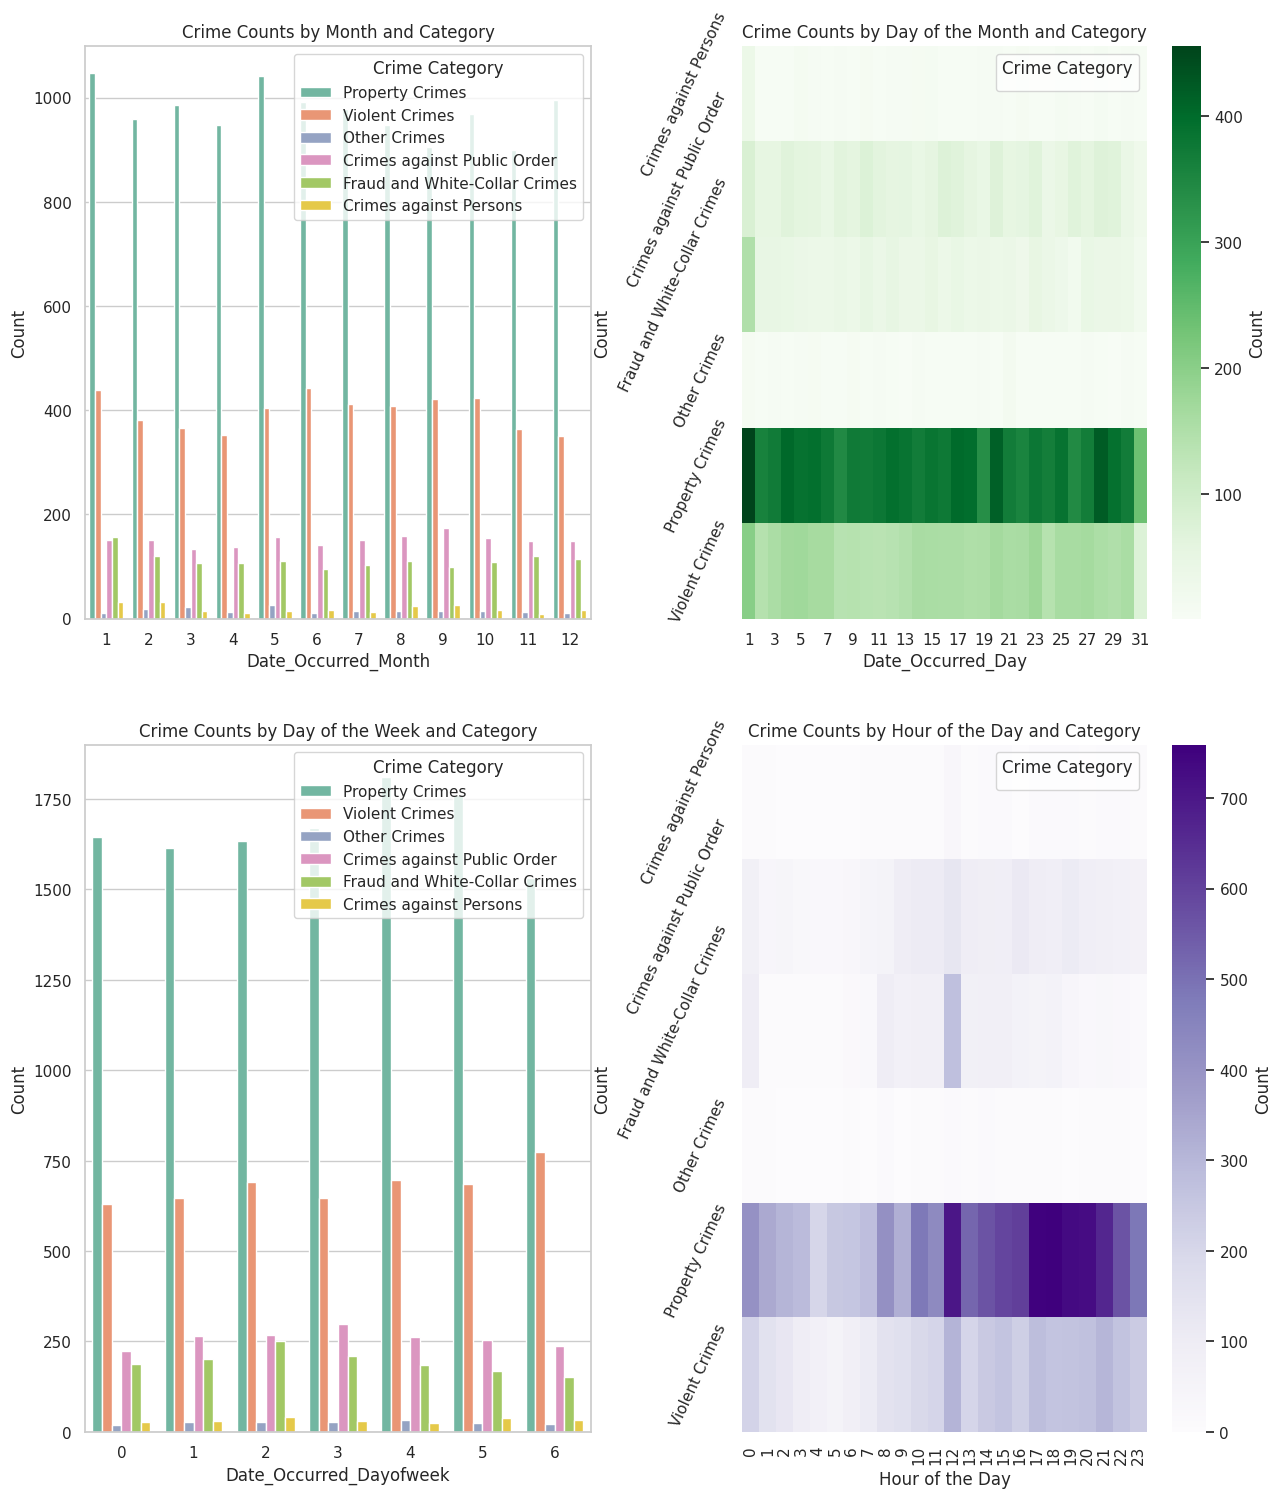

In [13]:
date_format = '%m/%d/%Y %I:%M:%S %p'

data = df.copy()
data['Date_Occurred_Month'] = pd.to_datetime(data.Date_Occurred, format=date_format).dt.month
data['Date_Occurred_Day'] = pd.to_datetime(data.Date_Occurred, format=date_format).dt.day
data['Date_Occurred_Dayofweek'] = pd.to_datetime(data.Date_Occurred, format=date_format).dt.dayofweek

#Main figure
fig = plt.figure(figsize=(15, 18))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], width_ratios=[1, 1], hspace=0.2, wspace=0.3)

#Plot 1: Bar Chart for Crime Categories by Month
ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(data=data, x='Date_Occurred_Month', hue='Crime_Category', palette='Set2', ax=ax1)
ax1.set_title('Crime Counts by Month and Category')
ax1.set_ylabel('Count')
ax1.legend(title='Crime Category')

#Plot 2: Bar Chart for Crime Categories by Date
ax2 = fig.add_subplot(gs[0, 1])
heatmap_data_date = data.groupby(['Crime_Category', 'Date_Occurred_Day']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data_date, cmap='Greens', ax=ax2, cbar_kws={'label': 'Count'})
ax2.set_title('Crime Counts by Day of the Month and Category')
ax2.set_ylabel('Count')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=65, ha='right')
ax2.legend(title='Crime Category')

#Plot 3: Bar Chart for Crime Categories by Day of the week
ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(data=data, x='Date_Occurred_Dayofweek', hue='Crime_Category', palette='Set2', ax=ax3)
ax3.set_title('Crime Counts by Day of the Week and Category')
ax3.set_ylabel('Count')
ax3.legend(title='Crime Category')

#Plot 3: Bar Chart for Crime Categories by Hour
ax4 = fig.add_subplot(gs[1, 1])
data['Hour_Occurred'] = data['Time_Occurred'].apply(lambda x: int(x // 100))
heatmap_data_hour = data.groupby(['Crime_Category', 'Hour_Occurred']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data_hour, cmap='Purples', ax=ax4, cbar_kws={'label': 'Count'})
ax4.set_title('Crime Counts by Hour of the Day and Category')
ax4.set_xlabel('Hour of the Day')
ax4.set_ylabel('Count')
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=65, ha='right')
ax4.legend(title='Crime Category')

plt.show()

### Observations
* Crimes are almost evenly distributed among all months.
* Crimes are more likely to occur on days 4 & 5 i.e., Friday & Saturday.
* Crimes are most likely to occur on the first day of the month.
* The probability of crimes occuring is highest at 12 in the afternoon and from 5 to 9 in the evening.

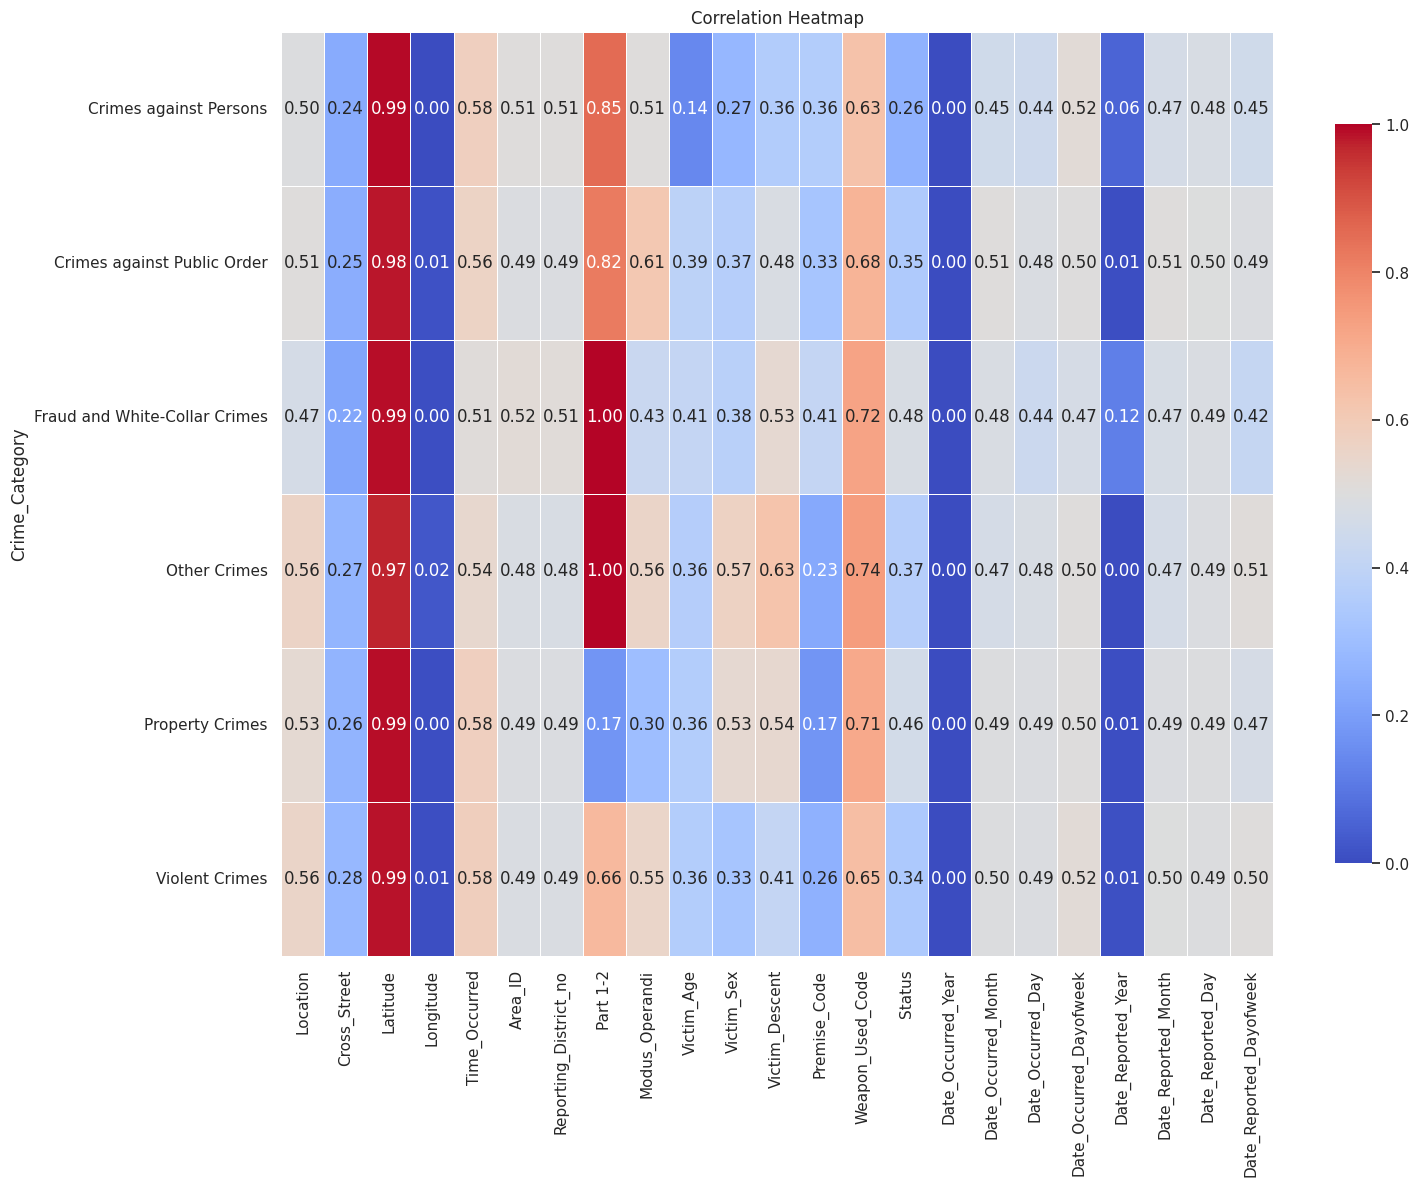

In [14]:
#Combining X and Y
data = X.copy()
data['Crime_Category'] = y

plt.figure(figsize=(16, 12))

#Heatmap
mean_values = data.groupby('Crime_Category').mean()
sns.heatmap(mean_values, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Correlation Heatmap')
plt.show()

### Most Important Features based on above heatmap

* Latitude
* Part 1-2
* Weapon_Used_Code
* Victim_Descent
* Modus_Operandi

In [15]:
#Summary statistics for preprocessed data
X.describe()

,Location,Cross_Street,Latitude,Longitude,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Modus_Operandi,Victim_Age,...,Weapon_Used_Code,Status,Date_Occurred_Year,Date_Occurred_Month,Date_Occurred_Day,Date_Occurred_Dayofweek,Date_Reported_Year,Date_Reported_Month,Date_Reported_Day,Date_Reported_Dayofweek
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.0,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,0.530184,0.262375,0.988715,0.006492,0.573104,0.491712,0.490744,0.418150,0.400427,0.364808,...,0.692461,0.418137,0.0,0.493845,0.485670,0.503742,0.015450,0.491823,0.493048,0.478017
std,0.295559,0.170687,0.061955,0.062174,0.274004,0.301658,0.287849,0.493267,0.302118,0.147934,...,0.180526,0.166874,0.0,0.314469,0.298115,0.329442,0.083736,0.313839,0.294072,0.328515
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.271253,0.208835,0.990710,0.001969,0.393978,0.250000,0.253340,0.000000,0.127956,0.288660,...,0.722222,0.500000,0.0,0.181818,0.233333,0.166667,0.000000,0.181818,0.233333,0.166667
50%,0.546741,0.208835,0.992152,0.002869,0.606022,0.500000,0.506202,0.000000,0.304586,0.298969,...,0.722222,0.500000,0.0,0.454545,0.500000,0.500000,0.000000,0.454545,0.500000,0.500000
75%,0.788938,0.208835,0.995250,0.003278,0.805344,0.750000,0.725668,1.000000,0.674962,0.453608,...,0.722222,0.500000,0.0,0.727273,0.733333,0.833333,0.000000,0.727273,0.733333,0.833333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


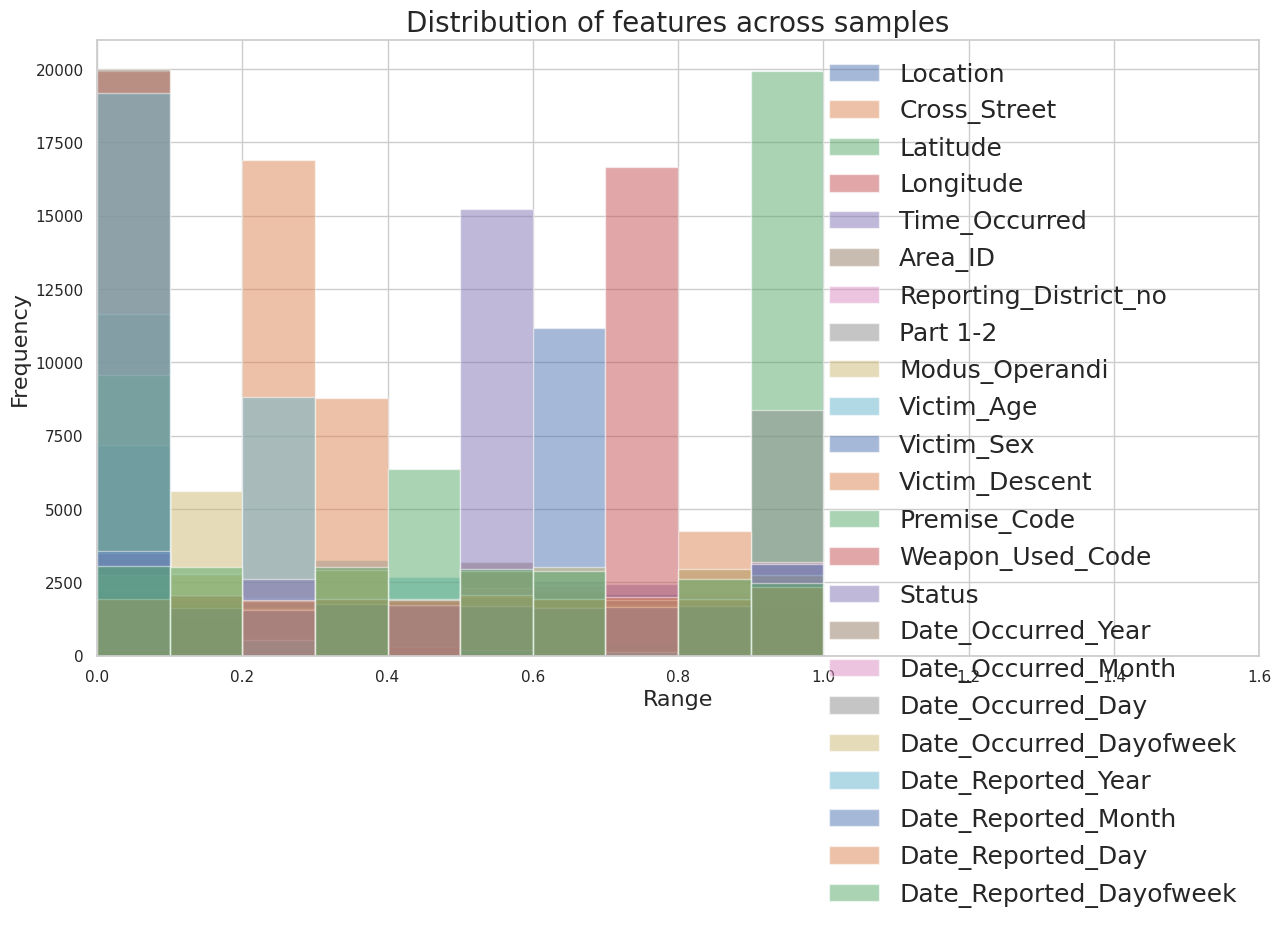

In [16]:
#Histogram
fig = plt.figure(figsize=(15,8))

ax = fig.add_subplot(111)
ax.set_xlim(left=0, right=1.6)

for colname in X:
    plt.hist(X[colname].values, alpha=0.5)

#Name the curves of features
in_cols = list(X)

plt.legend(in_cols, fontsize=18,loc="upper right",frameon=False)
plt.title('Distribution of features across samples',fontsize=20)
plt.xlabel('Range',fontsize=16)
plt.ylabel('Frequency',fontsize=16)

plt.show()

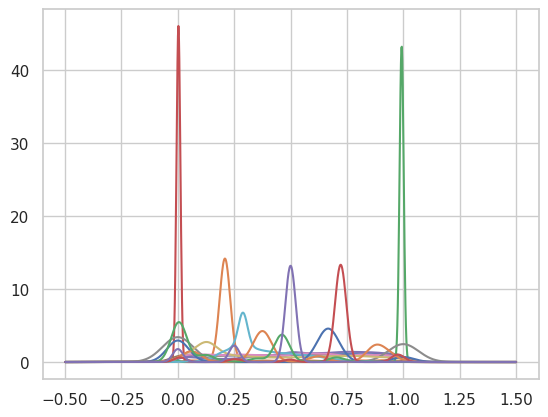

In [17]:
#KDE Plot to view range of preprocessed data
try:
    ax = X.plot.kde()
except Exception as e:
    pass

The above two plots show the distribution of features after scaling.

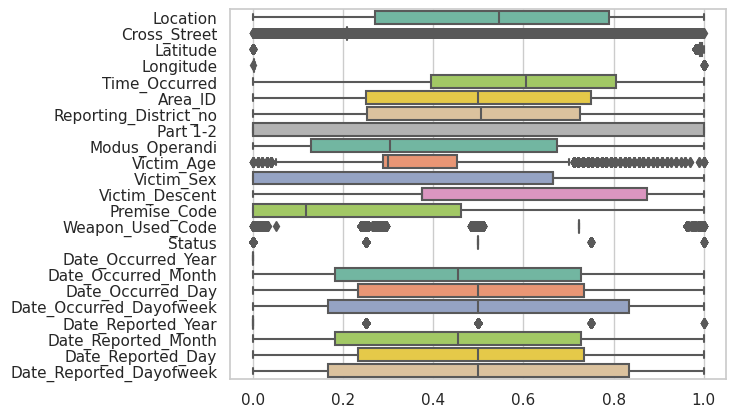

In [18]:
#Boxplot
ax = sns.boxplot(data=X, orient="h", palette="Set2")
plt.show()

As we can see, victim age has the highest number of outliers.

In [19]:
#Splitting the training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# #KNN WITH PCA

# #Defining the PCA and KNN model pipeline
# pipeline = Pipeline([
#     ('pca', PCA()),
#     ('knn', KNeighborsClassifier())
# ])

# #Define the parameter grid for GridSearchCV
# param_grid = {
#     'pca__n_components': [10, 15], #Number of components to retain
#     'knn__n_neighbors': [13, 15], #Number of neighbors
#     'knn__weights': ['uniform', 'distance'], #Weight function
#     'knn__metric': ['euclidean', 'manhattan'] #Distance metric for KNN
# }

# #Setting up GridSearchCV
# grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# #Fitting the model
# grid_search.fit(X_train, y_train)

# #Printing the best parameters and best score
# print("Best Parameters:", grid_search.best_params_)
# print("Best Score:", grid_search.best_score_)

# #Predicting and evaluating
# y_pred = grid_search.best_estimator_.predict(X_val)
# print("KNN Accuracy:", accuracy_score(y_val, y_pred))
# print(classification_report(y_val, y_pred, zero_division=0))

In [21]:
#DECISION TREE

#Defining the Decision Tree model
decision_tree = DecisionTreeClassifier()

#Defining the parameter grid for GridSearchCV
param_grid = {
    'decision_tree__criterion': ['gini', 'entropy'],  #Criterion for information gain
    'decision_tree__splitter': ['best', 'random'],    #Split strategy
    'decision_tree__max_depth': [None, 10, 20, 30],   #Maximum depth of the tree
    'decision_tree__min_samples_split': [2, 10, 20],  #Minimum samples needed to split an internal node
    'decision_tree__min_samples_leaf': [1, 5, 10],    #Minimum samples needed to be at a leaf node
    'decision_tree__max_features': [None, 'sqrt', 'log2']  #Features to consider when looking for the best split
}

#Setting up GridSearchCV with Decision Tree
grid_search = GridSearchCV(
    estimator=Pipeline([
        ('decision_tree', decision_tree)
    ]),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

#Fitting the model
grid_search.fit(X_train, y_train)

#Printing the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

#Predicting and evaluating
y_pred = grid_search.best_estimator_.predict(X_val)
print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, zero_division=0))

Best Parameters: {'decision_tree__criterion': 'gini', 'decision_tree__max_depth': None, 'decision_tree__max_features': None, 'decision_tree__min_samples_leaf': 5, 'decision_tree__min_samples_split': 20, 'decision_tree__splitter': 'best'}
Best Score: 0.8675625
Decision Tree Accuracy: 0.86225
                               precision    recall  f1-score   support

       Crimes against Persons       0.57      0.50      0.53        32
  Crimes against Public Order       0.66      0.67      0.66       374
Fraud and White-Collar Crimes       0.90      0.84      0.87       267
                 Other Crimes       0.32      0.17      0.22        35
              Property Crimes       0.94      0.95      0.94      2303
               Violent Crimes       0.78      0.77      0.77       989

                     accuracy                           0.86      4000
                    macro avg       0.69      0.65      0.67      4000
                 weighted avg       0.86      0.86      0.86      4

In [22]:
# #LOGISTIC REGRESSION

# #Parameter grid
# lreg_grid = {
#     'C': [0.01, 0.1, 1, 10],
#     'solver': ['liblinear', 'saga'],
#     'max_iter': [3000]
# }

# #Grid Search
# lreg = LogisticRegression(random_state=42)
# lreg_grid_search = GridSearchCV(estimator=lreg, param_grid=lreg_grid, cv=5, n_jobs=-1, scoring='accuracy')
# lreg_grid_search.fit(X_train, y_train)

# #Best parameters and score
# print("Best Logistic Regression Parameters:", lreg_grid_search.best_params_)
# print("Best Logistic Regression Score:", lreg_grid_search.best_score_)

# #Predicting and evaluating
# y_pred_lreg = lreg_grid_search.best_estimator_.predict(X_val)
# print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lreg))
# print(classification_report(y_val, y_pred_lreg, zero_division=0))

In [23]:
#RANDOM FOREST CLASSIFIER

#Parameter Grid with parameters range
param_distributions = {
    'n_estimators': randint(50, 200), #Number of trees
    'max_depth': randint(5, 50),  #Max depth of trees
    'min_samples_split': randint(2, 20), #Minimum samples needed to split an internal node
    'min_samples_leaf': randint(1, 20), #Minimum samples needed to be a leaf node
    'max_features': ['sqrt', 'log2', None] #Features to consider when looking for the best split
}

#Initializing Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

#Initializing the RandomSearchCV object
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,  # Number of parameter settings to sample
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

#Fitting the random search CV object
random_search.fit(X_train, y_train)

#Best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

#Predicting and evaluating
y_pred = random_search.best_estimator_.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Best Parameters: {'max_depth': 39, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 90}
Best Score: 0.8957499999999999
Random Forest Accuracy: 0.8925
                               precision    recall  f1-score   support

       Crimes against Persons       0.66      0.59      0.62        32
  Crimes against Public Order       0.78      0.67      0.72       374
Fraud and White-Collar Crimes       0.95      0.86      0.91       267
                 Other Crimes       0.36      0.11      0.17        35
              Property Crimes       0.96      0.95      0.96      2303
               Violent Crimes       0.78      0.89      0.83       989

                     accuracy                           0.89      4000
                    macro avg       0.75      0.68      0.70      4000
                 weighted avg       0.89      0.89      0.89      4000



In [24]:
# #STACKING WITH XGBCLASSIFIER AS META MODEL

# #Encoding the target column to numerical as XGB only accepts numerical inputs
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y_train)

# #Parameter grid for random forest
# param_grid_rf = {
#     'n_estimators': [50, 100],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5]
# }

# #Parameter grid for gradient boosting
# param_grid_gb = {
#     'n_estimators': [50, 100],
#     'learning_rate': [0.01, 0.1],
#     'max_depth': [3, 5]
# }


# #Parameter grid for bagging
# param_grid_bag = {
#     'n_estimators': [10, 20],
#     'estimator__n_estimators': [10, 50]
# }

# #Performing GridSearchCV for each model
# grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, n_jobs=-1, scoring='accuracy')
# grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=3, n_jobs=-1, scoring='accuracy')
# grid_bag = GridSearchCV(BaggingClassifier(estimator=RandomForestClassifier(), random_state=42), param_grid_bag, cv=3, n_jobs=-1, scoring='accuracy')

# #Fitting the grid searches
# grid_rf.fit(X_train, y_encoded)
# grid_gb.fit(X_train, y_encoded)
# grid_bag.fit(X_train, y_encoded)

# #Best estimators from GridSearchCV
# best_rf = grid_rf.best_estimator_
# best_gb = grid_gb.best_estimator_
# best_bag = grid_bag.best_estimator_

# #Defining the meta-model
# meta_model = XGBClassifier(random_state=42)

# #Initializing Stack Classifier
# stacking = StackingClassifier(
#     estimators=[
#         ('rf', best_rf),
#         ('gb', best_gb),
#         ('bag', best_bag)
#     ],
#     final_estimator=meta_model,
#     cv=3,  # Reduced cross-validation folds
#     n_jobs=-1  # Use all available cores
# )

# #Fitting the stacking model
# stacking.fit(X_train, y_encoded)

# #Predicting
# y_pred = stacking.predict(X_val)

# #Converting numeric predictions back to original text labels
# y_pred = label_encoder.inverse_transform(y_pred)

# #Evaluating
# print("Stacking Classifier Accuracy:", accuracy_score(y_val, y_pred))
# print(classification_report(y_val, y_pred))

In [25]:
# #GRADIENT BOOSTING
# #Parameter grid
# gb_grid = {
#     'n_estimators': [100, 200],
#     'learning_rate': [0.1, 0.2],
#     'max_depth': [4, 5]
# }

# #Grid Search
# gb = GradientBoostingClassifier(random_state=42)
# gb_grid_search = GridSearchCV(estimator=gb, param_grid=gb_grid, cv=5, n_jobs=-1, scoring='accuracy')
# gb_grid_search.fit(X_train, y_train)

# #Best parameters and score
# print("Best Gradient Boosting Parameters:", gb_grid_search.best_params_)
# print("Best Gradient Boosting Score:", gb_grid_search.best_score_)

# #Predicting and evaluating
# y_pred_gb = gb_grid_search.best_estimator_.predict(X_val)
# print("Gradient Boosting Accuracy:", accuracy_score(y_val, y_pred_gb))
# print(classification_report(y_val, y_pred_gb))

In [26]:
#BAGGING

# #Defining the base estimator
# base_estimator = DecisionTreeClassifier()

# #Define Bagging model
# bagging = BaggingClassifier(estimator=base_estimator, random_state=42)

# #Define parameter grid
# param_distributions = {
#     'n_estimators': randint(10, 100),
#     'max_samples': [0.5, 0.7, 1.0],
#     'max_features': [0.5, 0.7, 1.0],
#     'bootstrap': [True, False],
#     'bootstrap_features': [True, False],
# }

# #Setting up RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator=bagging,
#     param_distributions=param_distributions,
#     n_iter=20,  # Number of parameter settings to sample
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,
#     random_state=42
# )

#Fitting randomized search
# random_search.fit(X_train, y_train)

# #Printing the best parameters and best score
# print("Best Parameters:", random_search.best_params_)
# print("Best Score:", random_search.best_score_)

# #Predicting and evaluating
# y_pred = random_search.best_estimator_.predict(X_val)
# print("Bagging Accuracy:", accuracy_score(y_val, y_pred))
# print(classification_report(y_val, y_pred))

In [27]:
#LIGHT GRADIENT BOOSTING MODEL

#Encoding target column to numerical as gradient boosting only accepts numerical input
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)

#Fitting a RandomForest to get feature importances
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_encoded)

#Sorting feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

#Selecting top 15 features
N = 15
top_indices = indices[:N]
top_feature_names = X_train.columns[top_indices]
X_train_encoded = X_train[top_feature_names]
X_val_encoded = X_val[top_feature_names]

#Defining parameter grid
param_grid = {
    'num_leaves': randint(20, 150),
    'max_depth': randint(5, 30),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': randint(50, 300),
    'min_child_samples': randint(5, 50),
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0]
}

#Creating the model
model = lgb.LGBMClassifier(random_state=42, verbose=-1)

#Randomized Search
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train_encoded, y_encoded)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

#Predicting
y_pred = random_search.predict(X_val_encoded)

#Converting numeric predictions back to original text labels
y_pred = label_encoder.inverse_transform(y_pred)

#Evaluating
print("LightGBM Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Best Parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.2, 'max_depth': 26, 'min_child_samples': 48, 'n_estimators': 138, 'num_leaves': 68, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 1.0}
Best Score: 0.8979378351191944
LightGBM Accuracy: 0.89525
                               precision    recall  f1-score   support

       Crimes against Persons       0.61      0.62      0.62        32
  Crimes against Public Order       0.75      0.64      0.69       374
Fraud and White-Collar Crimes       0.92      0.87      0.89       267
                 Other Crimes       0.62      0.14      0.23        35
              Property Crimes       0.96      0.96      0.96      2303
               Violent Crimes       0.80      0.87      0.83       989

                     accuracy                           0.90      4000
                    macro avg       0.78      0.69      0.71      4000
                 weighted avg       0.89      0.90      0.89      4000



In [28]:
#Initializing fresh model with best parameters and early stopping
lgbm = lgb.LGBMClassifier(**random_search.best_params_, random_state=42, verbose=-1)
lgbm.fit(X_train_encoded, y_encoded, eval_set=[(X_val_encoded, label_encoder.fit_transform(y_val))], callbacks=[lgb.early_stopping(stopping_rounds=50)])

#Predicting
y_pred = lgbm.predict(X_val_encoded)

#Converting numeric predictions back to original text labels
y_pred = label_encoder.inverse_transform(y_pred)

#Evaluating
print("LightGBM Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[26]	valid_0's multi_logloss: 0.289692
LightGBM Accuracy: 0.89825
                               precision    recall  f1-score   support

       Crimes against Persons       0.58      0.59      0.58        32
  Crimes against Public Order       0.77      0.67      0.72       374
Fraud and White-Collar Crimes       0.93      0.86      0.89       267
                 Other Crimes       0.60      0.09      0.15        35
              Property Crimes       0.96      0.96      0.96      2303
               Violent Crimes       0.80      0.88      0.84       989

                     accuracy                           0.90      4000
                    macro avg       0.77      0.68      0.69      4000
                 weighted avg       0.90      0.90      0.90      4000



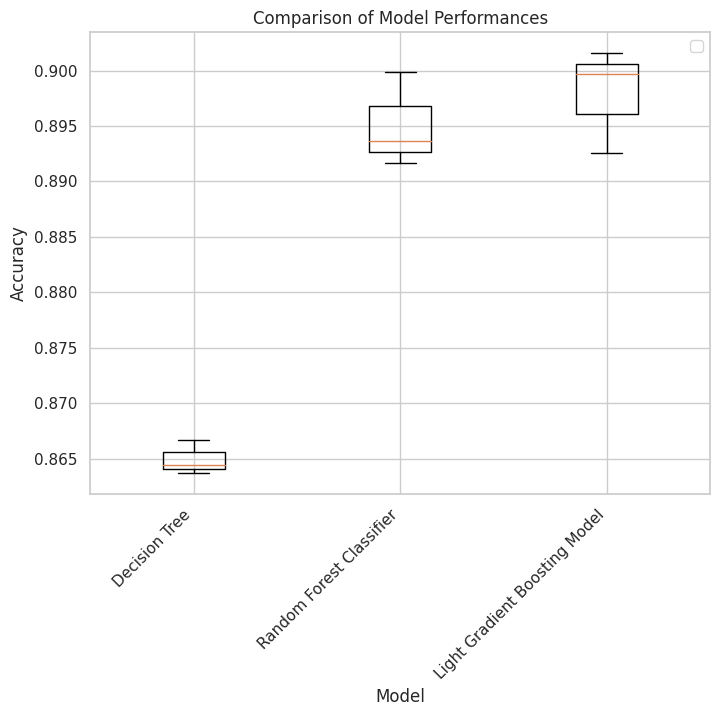

In [29]:
#Visual comparison of model performance
models = [grid_search, random_search, lgbm]
model_names = ['Decision Tree', 'Random Forest Classifier', 'Light Gradient Boosting Model']

#Evaluating models using cross-validation
scores = []
for model in models:
    cv_scores = cross_val_score(model, X_train_encoded, y_encoded, cv=3, n_jobs=-1, scoring='accuracy')
    scores.append(cv_scores)

#Creating plot
fig, ax = plt.subplots(figsize=(8, 6))

#Plotting the model performances
ax.boxplot(scores, labels=model_names)
ax.set_title('Comparison of Model Performances')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
ax.legend()

plt.show()

In [30]:
#Reading the test data
X_test = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/test.csv")
X_test.head()

#Preprocessing test data
X_test = data_preprocessing(X_test)
X_test.head()

,Location,Cross_Street,Latitude,Longitude,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Modus_Operandi,Victim_Age,...,Weapon_Used_Code,Status,Date_Occurred_Year,Date_Occurred_Month,Date_Occurred_Day,Date_Occurred_Dayofweek,Date_Reported_Year,Date_Reported_Month,Date_Reported_Day,Date_Reported_Dayofweek
0,0.233189,0.386447,0.990832,0.002914,0.847752,0.10,0.131202,1.0,0.335811,0.268041,...,0.720482,0.50,0.0,0.181818,0.066667,0.166667,0.0,0.181818,0.066667,0.166667
1,0.015370,0.386447,0.992574,0.002928,0.720526,0.95,0.912691,0.0,0.158446,0.247423,...,0.720482,0.50,0.0,0.272727,0.800000,0.833333,0.0,0.454545,0.000000,0.000000
2,0.446926,0.386447,0.988560,0.003209,0.381255,0.85,0.831584,1.0,0.842230,0.618557,...,0.720482,0.50,0.0,0.636364,0.866667,0.500000,0.0,0.636364,0.900000,0.666667
3,0.170989,0.386447,0.991907,0.002580,0.932570,0.30,0.316794,0.0,0.133446,0.288660,...,0.720482,0.50,0.0,1.000000,0.066667,0.500000,0.0,1.000000,0.733333,0.333333
4,0.087896,0.386447,0.995153,0.002359,0.054707,0.70,0.693702,1.0,0.710473,0.360825,...,0.720482,0.25,0.0,0.636364,0.933333,0.833333,0.0,0.636364,0.966667,1.000000


In [31]:
#Predicting on the test set
X_test = X_test[top_feature_names]
y_pred = lgbm.predict(X_test)

#Converting numeric predictions back to original text labels
y_pred = label_encoder.inverse_transform(y_pred)

In [32]:
#Converting to csv
submission = pd.DataFrame({"ID":np.arange(1,5001), "Crime_Category": y_pred})
submission.to_csv('submission.csv', index=False)